In [32]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt # NEW: For plotting
import seaborn as sns # NEW: For enhanced visualizations
# Set plot style
sns.set_theme(style="whitegrid")

# EDA

In [3]:
file_path = 'housing.csv'
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
    exit()

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()

In [10]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,"452,600.00",NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,"358,500.00",NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,"352,100.00",NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,"341,300.00",NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,"342,200.00",NEAR BAY
5,-122.25,37.85,52,919,213.0,413,193,4.0368,"269,700.00",NEAR BAY
6,-122.25,37.84,52,2535,489.0,1094,514,3.6591,"299,200.00",NEAR BAY
7,-122.25,37.84,52,3104,687.0,1157,647,3.1200,"241,400.00",NEAR BAY
8,-122.26,37.84,42,2555,665.0,1206,595,2.0804,"226,700.00",NEAR BAY
9,-122.25,37.84,52,3549,707.0,1551,714,3.6912,"261,100.00",NEAR BAY


In [11]:
df.tail(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
20630,-121.32,39.29,11,2640,505.0,1257,445,3.5673,"112,000.00",INLAND
20631,-121.40,39.33,15,2655,493.0,1200,432,3.5179,"107,200.00",INLAND
20632,-121.45,39.26,15,2319,416.0,1047,385,3.1250,"115,600.00",INLAND
20633,-121.53,39.19,27,2080,412.0,1082,382,2.5495,"98,300.00",INLAND
20634,-121.56,39.27,28,2332,395.0,1041,344,3.7125,"116,800.00",INLAND
20635,-121.09,39.48,25,1665,374.0,845,330,1.5603,"78,100.00",INLAND
20636,-121.21,39.49,18,697,150.0,356,114,2.5568,"77,100.00",INLAND
20637,-121.22,39.43,17,2254,485.0,1007,433,1.7000,"92,300.00",INLAND
20638,-121.32,39.43,18,1860,409.0,741,349,1.8672,"84,700.00",INLAND
20639,-121.24,39.37,16,2785,616.0,1387,530,2.3886,"89,400.00",INLAND


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  object 
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(4), int64(4), object(2)
memory usage: 1.6+ MB


In [9]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [12]:
def clean_numeric_column(series):
    # Remove quotes, commas, and spaces, then convert to float
    return series.astype(str).str.replace(r'[",\s]', '', regex=True).astype(float)


In [13]:
# Clean the two columns that have string formatting issues
df['median_house_value'] = clean_numeric_column(df['median_house_value'])
df['median_income'] = clean_numeric_column(df['median_income'])

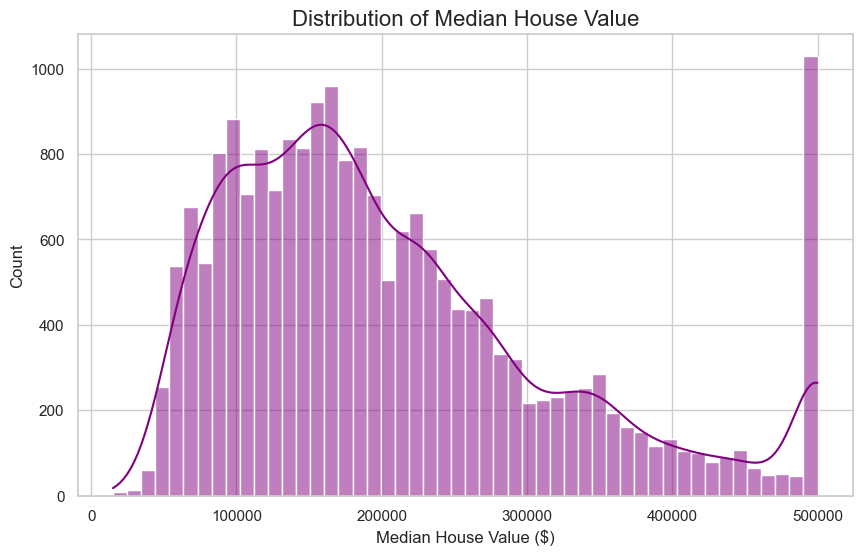

In [14]:
# Target Variable Distribution ---
plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='purple')
plt.title('Distribution of Median House Value', fontsize=16)
plt.xlabel('Median House Value ($)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

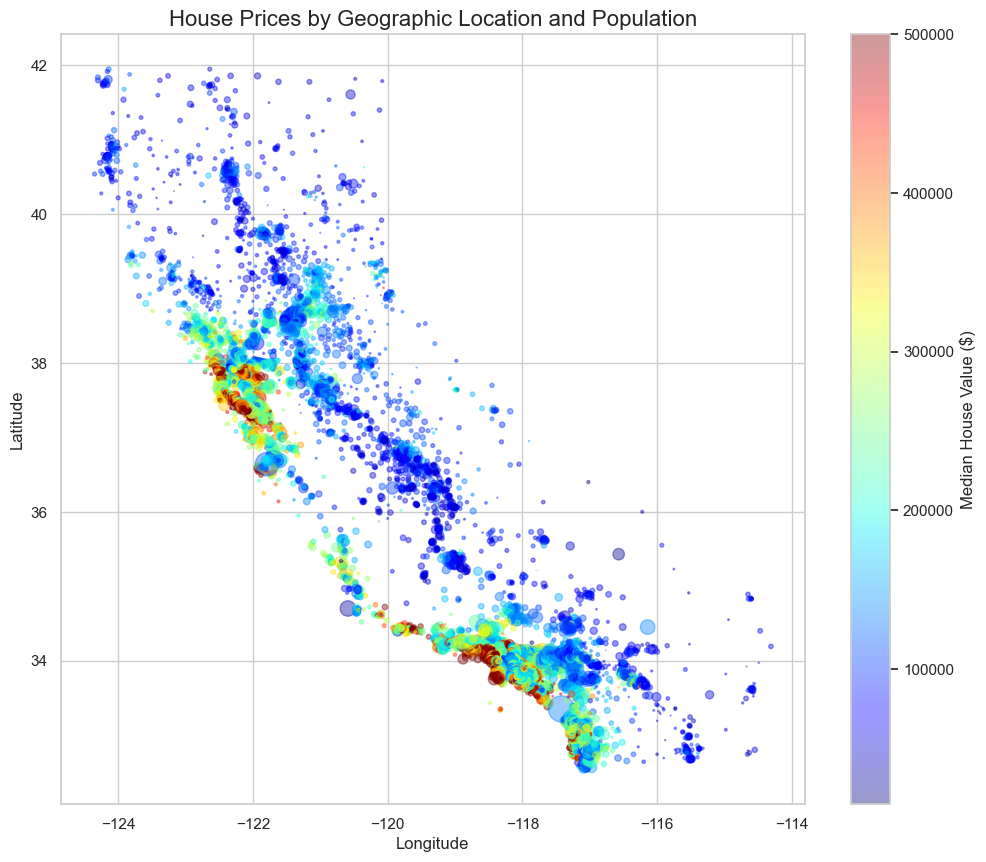

In [15]:
# Geographic Distribution of House Prices ---
plt.figure(figsize=(12, 10))
plt.scatter(
    x=df['longitude'], 
    y=df['latitude'], 
    alpha=0.4,
    s=df['population'] / 100,  # Size represents population
    c=df['median_house_value'], # Color represents house value
    cmap=plt.get_cmap("jet")
)
cbar = plt.colorbar(label='Median House Value ($)')
plt.title('House Prices by Geographic Location and Population', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.show()


# Feature Engineering 


In [16]:
print("\n--- Performing Feature Engineering ---")

# 1. Rooms per household
df['rooms_per_household'] = df['total_rooms'] / df['households']

# 2. Bedrooms per room (indicator of property density/age)
df['bedrooms_per_room'] = df['total_bedrooms'] / (df['total_rooms'] + 1e-6)

# 3. Population per household
df['population_per_household'] = df['population'] / df['households']

# Drop the original columns that were combined into ratios
df.drop(['total_rooms', 'total_bedrooms', 'population', 'households'], axis=1, inplace=True)



--- Performing Feature Engineering ---


In [17]:
df.head(10)

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467
5,-122.25,37.85,52,4.0368,269700.0,NEAR BAY,4.761658,0.231774,2.139896
6,-122.25,37.84,52,3.6591,299200.0,NEAR BAY,4.931907,0.192899,2.128405
7,-122.25,37.84,52,3.1200,241400.0,NEAR BAY,4.797527,0.221327,1.788253
8,-122.26,37.84,42,2.0804,226700.0,NEAR BAY,4.294118,0.260274,2.026891
9,-122.25,37.84,52,3.6912,261100.0,NEAR BAY,4.970588,0.199211,2.172269


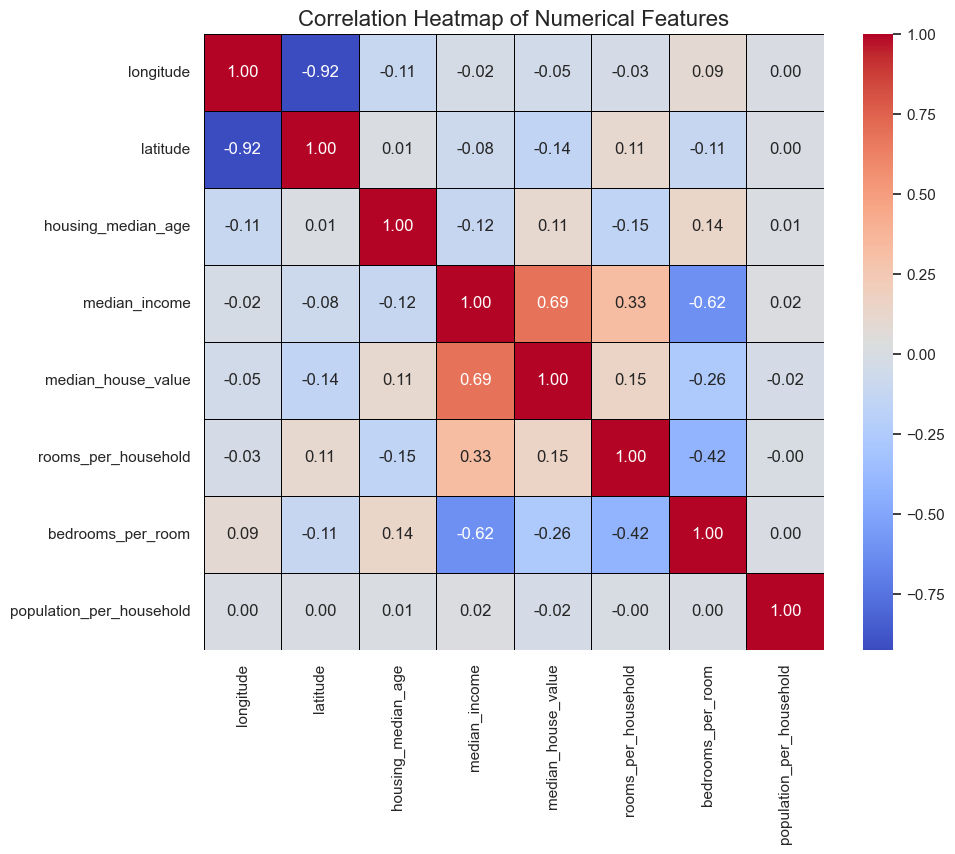

In [18]:
# Correlation Heatmap 
plt.figure(figsize=(10, 8))
# Select only numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=np.number)
correlation_matrix = numerical_df.corr()
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f",
    linewidths=.5,
    linecolor='black'
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()


# ML

In [30]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [22]:
# Define Features, Target 
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [23]:
# Identify numerical and categorical features after feature engineering
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()


In [25]:
numerical_features

['longitude',
 'latitude',
 'housing_median_age',
 'median_income',
 'rooms_per_household',
 'bedrooms_per_room',
 'population_per_household']

In [26]:
categorical_features

['ocean_proximity']

In [41]:
# Preprocessing Pipeline Setup ---
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='passthrough')

print("Preprocessing ColumnTransformer setup complete.")

Preprocessing ColumnTransformer setup complete.


In [45]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'median_income', 'rooms_per_household',
                                  'bedrooms_per_room',
                                  'population_per_household']),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['ocean_proximity'])])

In [42]:
# Split Data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Data split: Training samples={len(X_train)}, Test samples={len(X_test)}")


Data split: Training samples=16512, Test samples=4128


In [46]:
# Hyperparameter Tuning and Cross-Validation for Multiple Models

models = {
      "RandomForest": {
            "model": RandomForestRegressor(random_state=42, n_jobs=-1),
            "params": {
                'regressor__n_estimators': [50, 100, 150, 200, 250],
                'regressor__max_features': [2, 4, 6, 8], 
                'regressor__max_depth': [10, 20, 30, 40],
                'regressor__min_samples_split': [2, 4, 6, 8],
            }
        },
        "GradientBoosting": {
            "model": GradientBoostingRegressor(random_state=42),
            "params": {
                'regressor__n_estimators': [100, 200, 300], 
                'regressor__learning_rate': [0.01, 0.05, 0.1, 0.2], 
                'regressor__max_depth': [3, 5, 7],
                'regressor__subsample': [0.6, 0.8, 1.0], 
            }
        },
        "LinearRegression": {
            "model": LinearRegression(),
            "params": {
                'regressor__fit_intercept': [True, False],
        }
    }
}


In [49]:
# Train the data 

final_results = {}
best_final_model = None
lowest_rmse = float('inf')

for model_name, config in models.items():
    print(f"\n- Starting Hyperparameter Tuning for {model_name} (5-fold CV) -")
    
    # Build the complete pipeline: Preprocessor -> Model
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', config["model"])
    ])

    # Randomized Search setup
    n_iter = 10 if model_name != "LinearRegression" else 2 
    
    rnd_search = RandomizedSearchCV(
        full_pipeline, 
        param_distributions=config["params"],
        n_iter=n_iter,
        cv=5,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    # Train and find the best parameters
    rnd_search.fit(X_train, y_train)
    
    # Evaluate performance
    best_rmse_cv = np.sqrt(-rnd_search.best_score_)
    y_pred = rnd_search.best_estimator_.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Store results (initialize the inner dictionary first)
    final_results[model_name] = {} 
    final_results[model_name]['CV RMSE'] = best_rmse_cv
    final_results[model_name]['Test RMSE'] = test_rmse
    final_results[model_name]['Best Params'] = rnd_search.best_params_
    
    print(f"Completed {model_name}. Test RMSE:{test_rmse}")

    # Track the overall best model
    if test_rmse < lowest_rmse:
        lowest_rmse = test_rmse
        best_final_model = rnd_search.best_estimator_


- Starting Hyperparameter Tuning for RandomForest (5-fold CV) -
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Completed RandomForest. Test RMSE:47052.085386092636

- Starting Hyperparameter Tuning for GradientBoosting (5-fold CV) -
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Completed GradientBoosting. Test RMSE:44842.94480670851

- Starting Hyperparameter Tuning for LinearRegression (5-fold CV) -
Fitting 5 folds for each of 2 candidates, totalling 10 fits
Completed LinearRegression. Test RMSE:72044.57712771033


In [82]:
# Summary 
results_df = pd.DataFrame.from_dict(final_results, orient='index')
results_df['CV RMSE'] = results_df['CV RMSE'].apply(lambda x: f'{x:,.2f}')
results_df['Test RMSE'] = results_df['Test RMSE'].apply(lambda x: f'{x:,.2f}')

pd.set_option('display.max_colwidth', None)
display(results_df)


,CV RMSE,Test RMSE,Best Params
RandomForest,"47,644.90","47,052.09","{'regressor__n_estimators': 250, 'regressor__min_samples_split': 2, 'regressor__max_features': 2, 'regressor__max_depth': 40}"
GradientBoosting,"46,786.56","44,842.94","{'regressor__subsample': 1.0, 'regressor__n_estimators': 200, 'regressor__max_depth': 7, 'regressor__learning_rate': 0.1}"
LinearRegression,"70,632.44","72,044.58",{'regressor__fit_intercept': True}


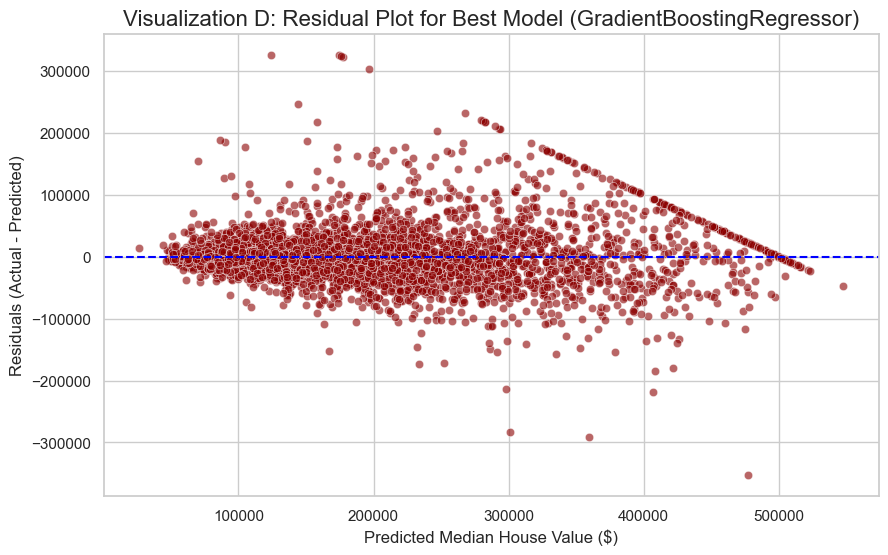

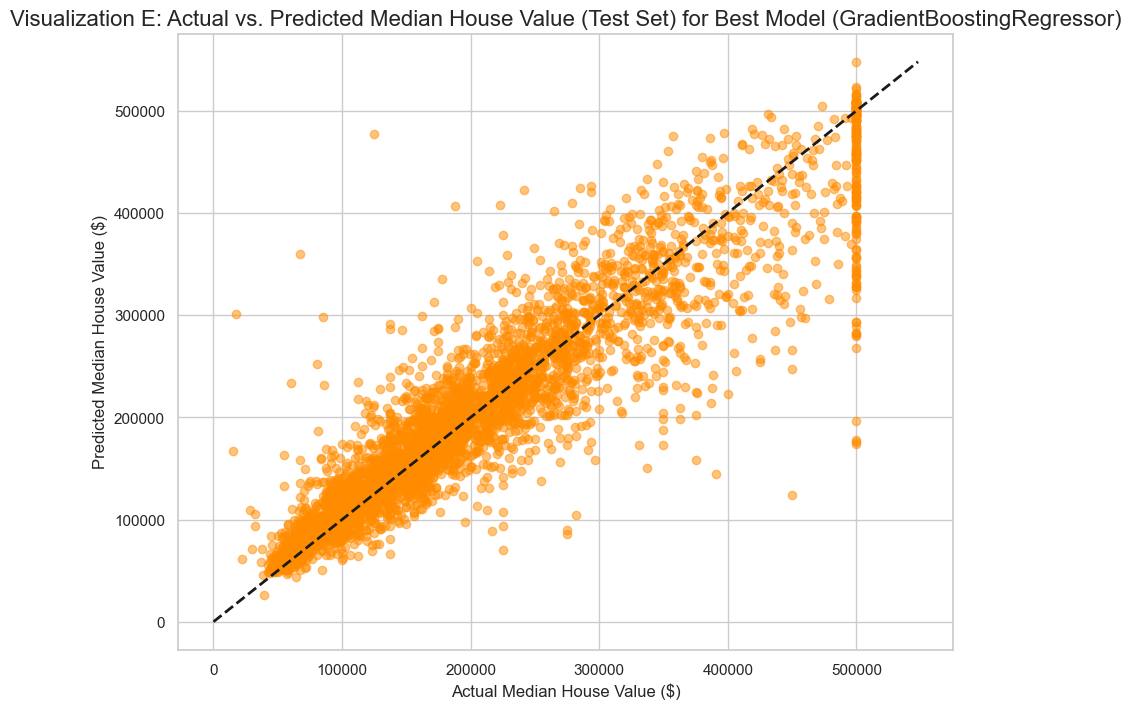

Final visualizations generated for the best model: GradientBoostingRegressor.


In [83]:
if best_final_model is not None:
    # Predict using the best model
    y_pred_best = best_final_model.predict(X_test)
    y_test_np = np.array(y_test)
    best_model_name = type(best_final_model["regressor"]).__name__
    
    # --- VISUALIZATION D: Residual Plot ---
    residuals = y_test_np - y_pred_best
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred_best, y=residuals, alpha=0.6, color='darkred')
    plt.axhline(y=0, color='blue', linestyle='--')
    plt.title(f'Visualization D: Residual Plot for Best Model ({best_model_name})', fontsize=16)
    plt.xlabel('Predicted Median House Value ($)', fontsize=12)
    plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
    plt.show()

    # --- VISUALIZATION E: Prediction vs. Actual ---
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test, y_pred_best, alpha=0.5, color='darkorange')
    max_val = max(y_test_np.max(), y_pred_best.max())
    plt.plot([0, max_val], [0, max_val], 'k--', lw=2) 
    plt.title(f'Visualization E: Actual vs. Predicted Median House Value (Test Set) for Best Model ({best_model_name})', fontsize=16)
    plt.xlabel('Actual Median House Value ($)', fontsize=12)
    plt.ylabel('Predicted Median House Value ($)', fontsize=12)
    plt.show()

    print(f"Final visualizations generated for the best model: {best_model_name}.")
else:
    print("Error: Could not determine the best model for final plotting.")


| Visualization                | Purpose                             | What to Look For                                |
| ---------------------------- | ----------------------------------- | ----------------------------------------------- |
| **Residual Plot**            | Checks error randomness             | Should be scattered evenly around 0             |
| **Actual vs Predicted Plot** | Compares predictions to true values | Points should align closely along diagonal line |
